In [1]:
#data wrangling
import pandas as pd
import numpy as np

#data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#statistics
from scipy import stats

#display plots inside notebook
%matplotlib inline

In [2]:
df = pd.read_csv("data/amazon_uk_price.csv")

In [3]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


### Part 1: Understanding Product Categories
#### Business Question: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

Frequency Tables:
- Generate a frequency table for the product category.
- Which are the top 5 most listed product categories?

Visualizations:
- Display the distribution of products across different categories using a bar chart. If you face problems understanding the chart, do it for a subset of top categories.
- For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?

In [4]:
df.columns

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='object')

In [5]:
df.shape

(2443651, 9)

In [6]:
df.dtypes

uid                    int64
asin                  object
title                 object
stars                float64
reviews                int64
price                float64
isBestSeller            bool
boughtInLastMonth      int64
category              object
dtype: object

In [7]:
#frequency table for product category
frequency_table_category = df["category"].value_counts()
frequency_table_category

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Motorbike Chassis                            107
Alexa Built-In Devices                       107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

In [8]:
#top 5 most listed product categories
frequency_table_category_top5 = frequency_table_category[:5]
frequency_table_category_top5

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64

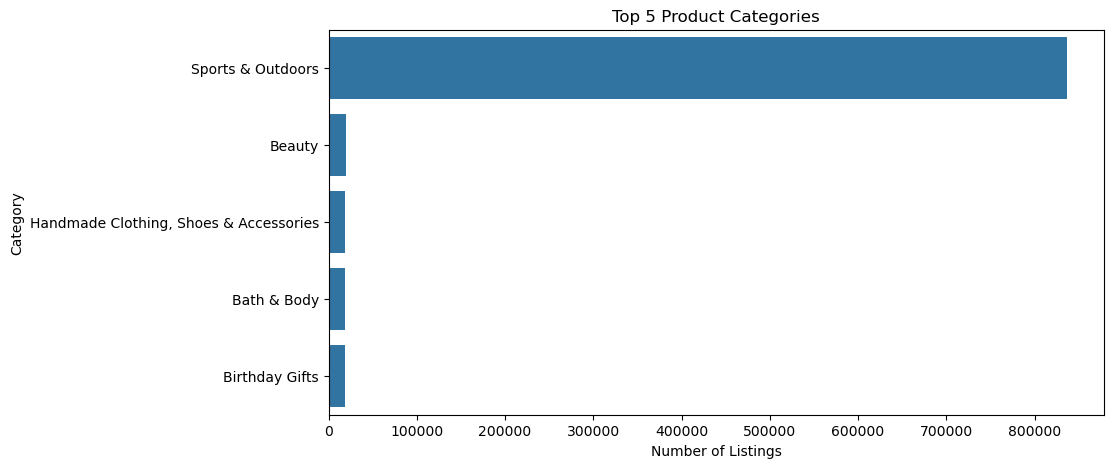

In [9]:
#visualization: distribution of products across different categories

plt.figure(figsize=(10,5))
sns.barplot(
    x=frequency_table_category_top5.values, 
    y=frequency_table_category_top5.index
)
plt.title("Top 5 Product Categories")
plt.xlabel("Number of Listings")
plt.ylabel("Category")

plt.show()

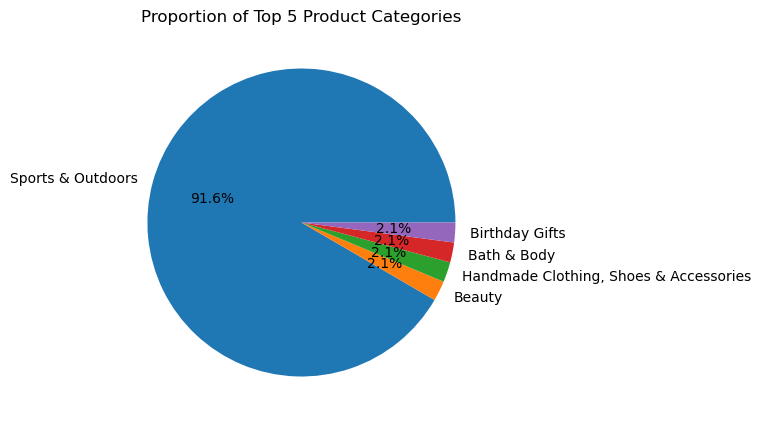

In [10]:
#For a subset of top categories, visualize their proportions using a pie chart
plt.figure(figsize=(5,5))
frequency_table_category_top5.plot(
    kind="pie",
    autopct="%1.1f%%", 
    ylabel=""
)
plt.title("Proportion of Top 5 Product Categories")

plt.show()

Among the top 5 product categories, Sports & Outdoors dominates the proportion of product categories by far with 91.6% of the products of this subset. The remaining four categories represent only a small fraction of the top five listings.

### Part 2: Delving into Product Pricing
#### Business Question: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

Measures of Centrality:
- Calculate the mean, median, and mode for the price of products.
- What's the average price point of products listed? How does this compare with the most common price point (mode)?

Measures of Dispersion:
- Determine the variance, standard deviation, range, and interquartile range for product price.
- How varied are the product prices? Are there any indicators of a significant spread in prices?

Visualizations:
- Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. If its hard to read these diagrams, think why this is, and explain how it could be solved..
- Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing.


In [11]:
#mean, median and mode
mean_price = df["price"].mean()
mean_price

np.float64(89.24380943923663)

In [12]:
median_price = df["price"].median()
median_price

19.09

In [13]:
mode_price = df["price"].mode()[0]
mode_price

np.float64(9.99)

#how does the average compare to the mode?
The average price of the listed products is 89.24 pounds, while the most common price is 9.99 pounds, suggesting that the price distribution is right-skewed, with relatively a small number of very expensive products increasing the average price.

In [14]:
#measures of dispersion: variance, std deviation, range, and interquartile range
variance_price = df["price"].var()
std_dev_price = df["price"].std()
min_price = df["price"].min()
max_price = df["price"].max()
price_range = max_price - min_price
q1 = df["price"].quantile(0.25)
q3 = df["price"].quantile(0.75)
iqr_price = q3 - q1

print(variance_price)
print(std_dev_price)
print(price_range)
print(iqr_price)

119445.48532256528
345.60886175352226
100000.0
36.0


#How varied are the product prices? Are there any indicators of a significant spread in prices?
The very large variance indicates that the prices vary considerably. Fifty percent of the products fall within a price range of 36 (iqr_price) but the overall price range of 100,000 suggests that there are some extremely expensive products. The standard deviation of 345.6 compared to the mean of 89 indicates that prices are highly dispersed, with many products having prices far from the average (outliers).

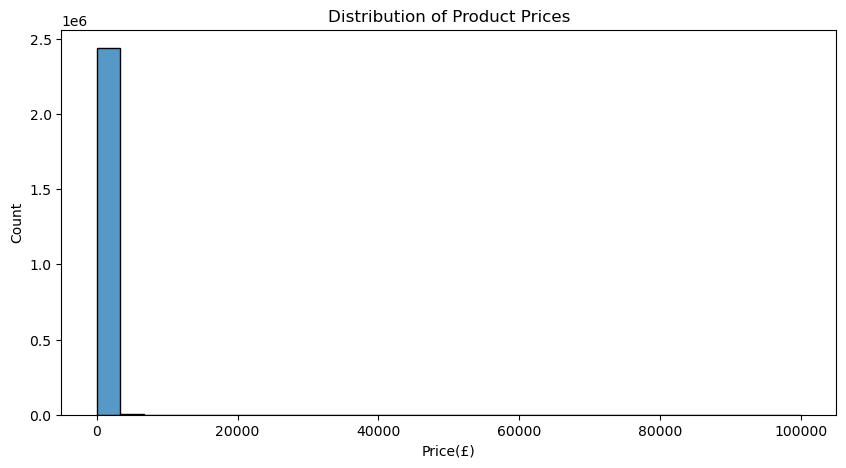

In [15]:
#visualizations: plot a histogram to visualize the distribution of product prices
plt.figure(figsize=(10,5))
sns.histplot(
    data=df,
    x="price", 
    bins=30
)
plt.title("Distribution of Product Prices")
plt.xlabel("Price(£)")
plt.ylabel("Count")

plt.show()

This graph is not readable because there are a few very expensive products enlarge the prices ranges to the right, while most of the products are considerably cheaper. One way to solve this could be by limiting the range of prices including only the ones where most products are.

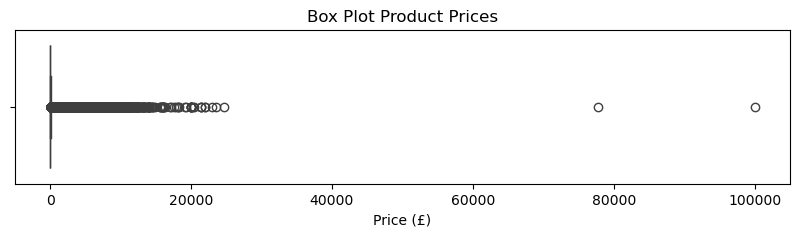

In [16]:
#visualization: using a box plot, show products that are significantly priced higher than the rest
plt.figure(figsize=(10,2))
sns.boxplot(
    x=df["price"]
)

plt.title("Box Plot Product Prices")
plt.xlabel("Price (£)")

plt.show()

The box plot shows that most products are have relatively low prices. It also reveals that there are a large number of high-price outliers and just a small portion are located far on the right. This confirms that product prices are highly right-skewed and that just a few products substantially increase the overall spread of prices.

### Part 3: Unpacking Product Ratings
#### Business Question: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

Measures of Centrality:
- Calculate the mean, median, and mode for the rating of products.
- How do customers generally rate products? Is there a common trend?

Measures of Dispersion:
- Determine the variance, standard deviation, and interquartile range for product rating.
- Are the ratings consistent, or is there a wide variation in customer feedback?

Shape of the Distribution:
- Calculate the skewness and kurtosis for the rating column.
- Are the ratings normally distributed, or do they lean towards higher or lower values?

Visualizations:
- Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?

In [17]:
df["stars"].unique()

array([4.7, 4.6, 4.5, 4.8, 0. , 4.4, 4.3, 4.1, 4.9, 5. , 3.8, 3.6, 4. ,
       4.2, 3. , 3.9, 2.5, 3.4, 3.7, 3.2, 3.3, 3.5, 2.7, 2.1, 1. , 3.1,
       2. , 2.9, 2.8, 1.5, 2.2, 2.3, 2.6, 2.4, 1.4, 1.9, 1.8, 1.7, 1.6,
       1.2, 1.3, 1.1])

In [18]:
#measures of centrality
avg_rating = df["stars"].mean()
median_rating = df["stars"].median()
mode_rating = df["stars"].mode()[0]

print(avg_rating)
print(median_rating)
print(mode_rating)

2.152836472966065
0.0
0.0


In [19]:
df["stars"].describe()

count    2.443651e+06
mean     2.152836e+00
std      2.194865e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      4.400000e+00
max      5.000000e+00
Name: stars, dtype: float64

In [20]:
df["stars"].value_counts().head(10)

stars
0.0    1225641
4.5     151577
4.6     136995
4.4     136165
5.0     128492
4.3     112564
4.7      94566
4.2      86871
4.0      66089
4.1      65115
Name: count, dtype: int64

#After calculating the median and mode and getting a result of 0.0, I checked for the description of the column and realized that most products have not yet received a review, which describes the low average rating of 2.15 and the respective 0.0 for both the median and the mode. However, if we wish to analyze only rated products, we could remove the 0.0 ratings.

In [22]:
#measures of dispersion
variance_stars = df["stars"].var()
std_dev_stars = df["stars"].std()
q1 = df["stars"].quantile(0.25)
q3 = df["stars"].quantile(0.75)
iqr_stars = q3 - q1

print(variance_stars)
print(std_dev_stars)
print(iqr_stars)

4.81743402976196
2.1948653785054697
4.4


The ratings show moderate variability, with a standard deviation of 2.19. The IQR of 4.4 indicates that the middle 50% of ratings span a wide range. However, these numbers are highly influence by the extremely large number of products with a rating of 0.0.

In [24]:
#shapes of distribution: calculate the skewness and kurtosis for the rating column
skewness_rating = df["stars"].skew()
kurtosis_rating = df["stars"].kurtosis()
print(skewness_rating)
print(kurtosis_rating)

0.08120735761080985
-1.9260061280432985


The skewness is close to zero (0.081), suggesting little overall asymmetry in the distribution. However, this result is influenced by the large number of products with a rating of 0.0, which likely represent unrated products. The negative kurtosis (-1.926) indicates a flatter distribution than a normal distribution, reflecting that ratings are spread across the available values rather than concentrated around a single peak.

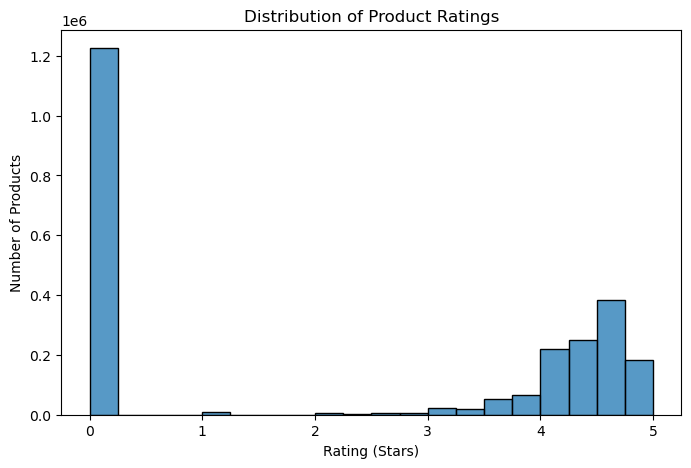

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="stars",
    bins=20
)

plt.title("Distribution of Product Ratings")
plt.xlabel("Rating (Stars)")
plt.ylabel("Number of Products")

plt.show()

The histogram reveals that 0.0 stars is the most frequent value due to a large number of unrated products. Among rated products, ratings are heavily concentrated between 4 and 5 stars, suggesting that most customer reviews are highly positive.